# Airline Sentiment Classification

A privacy-safe view of the chronological benchmark. The raw tweets are not rendered in this notebook; aggregate evidence is generated by the reusable package under src/airline_sentiment.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES = ROOT / 'outputs' / 'figures'

## Protocol

Exact duplicate IDs and duplicate text are removed first. The latest 20% of rows by timestamp form the untouched holdout. Candidate pipelines are selected using five-fold macro F1 on the earlier period only.

In [2]:
summary = json.loads((METRICS / 'evaluation_summary.json').read_text())
comparison = pd.read_csv(METRICS / 'model_comparison.csv')
display(pd.DataFrame([summary['holdout_metrics']]))
display(comparison)

,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,0.775121,0.727058,0.726099,0.774863


,model,cv_f1_macro,holdout_accuracy,holdout_balanced_accuracy,holdout_f1_macro,holdout_f1_weighted,best_parameters
0,logistic_regression,0.749039,0.775121,0.727058,0.726099,0.774863,"{""model__C"": 2.0, ""model__class_weight"": ""bala..."
1,complement_nb,0.732662,0.759182,0.702921,0.701249,0.755132,"{""model__alpha"": 0.1, ""tfidf__max_features"": 3..."
2,majority_baseline,0.259663,0.594941,0.333333,0.248678,0.443847,"{""tfidf__max_features"": 20000, ""tfidf__min_df""..."


## Class-Level Performance

,precision,recall,f1-score,support
negative,0.853078,0.855562,0.854318,1717.000000
neutral,0.653295,0.636872,0.644979,716.000000
positive,0.669528,0.688742,0.678999,453.000000
accuracy,0.775121,0.775121,0.775121,0.775121
macro avg,0.725300,0.727058,0.726099,2886.000000
weighted avg,0.774702,0.775121,0.774863,2886.000000


,metric,observed,ci_lower,ci_upper,n_boot,grouping,n_groups
0,accuracy,0.775121,0.758956,0.790657,2000,author_group,1633
1,balanced_accuracy,0.727058,0.707531,0.746446,2000,author_group,1633
2,f1_macro,0.726099,0.707409,0.744493,2000,author_group,1633
3,f1_weighted,0.774863,0.758416,0.790211,2000,author_group,1633


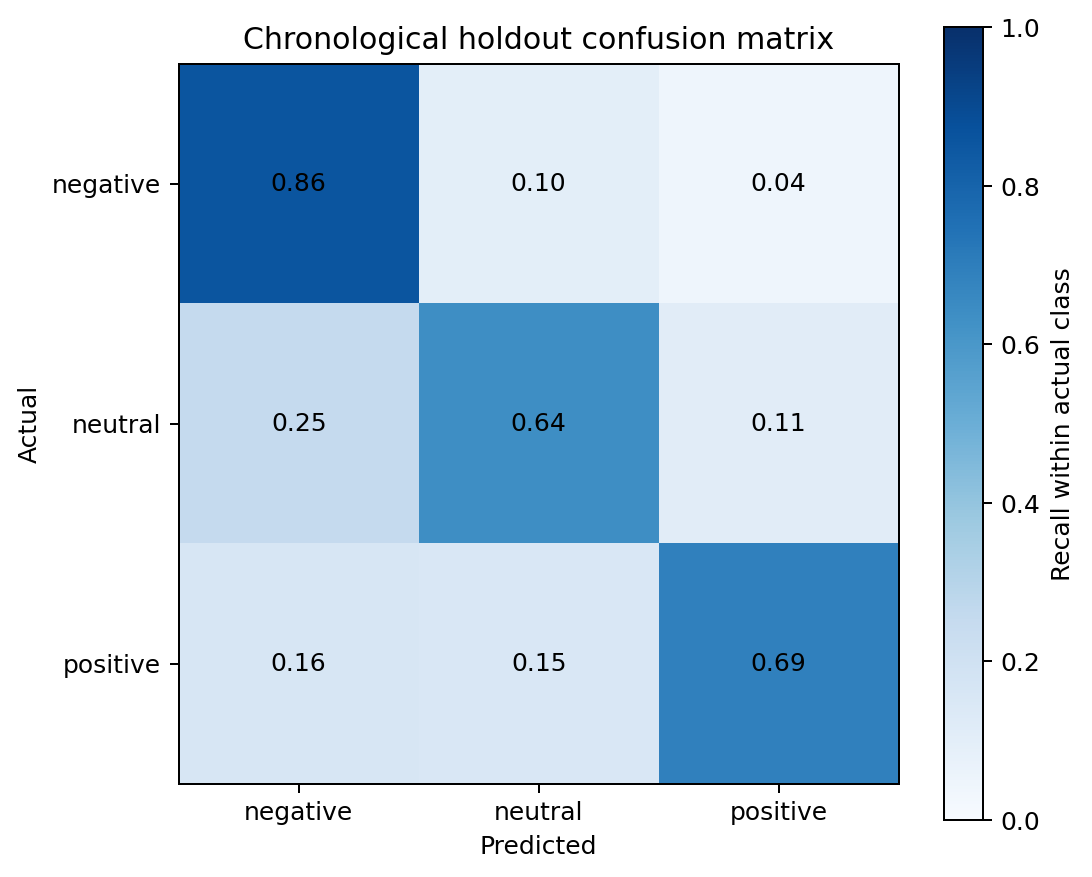

In [3]:
report = pd.read_csv(METRICS / 'classification_report.csv', index_col=0)
uncertainty = pd.read_csv(METRICS / 'holdout_uncertainty.csv')
display(report)
display(uncertainty)
display(Image(filename=str(FIGURES / 'confusion_matrix.png')))

## Interpretable Associations

Positive coefficients indicate features associated with each predicted class. They describe model behavior, not causes of customer sentiment.

,class,rank,feature,coefficient
0,negative,1,no,4.932924
1,negative,2,not,4.891136
2,negative,3,delayed,4.178759
3,negative,4,hours,4.085262
4,negative,5,worst,3.377493
5,negative,6,why,3.313618
6,negative,7,cancelled,3.254731
7,negative,8,delay,3.170476
8,negative,9,hour,3.048538
9,negative,10,your,2.823544


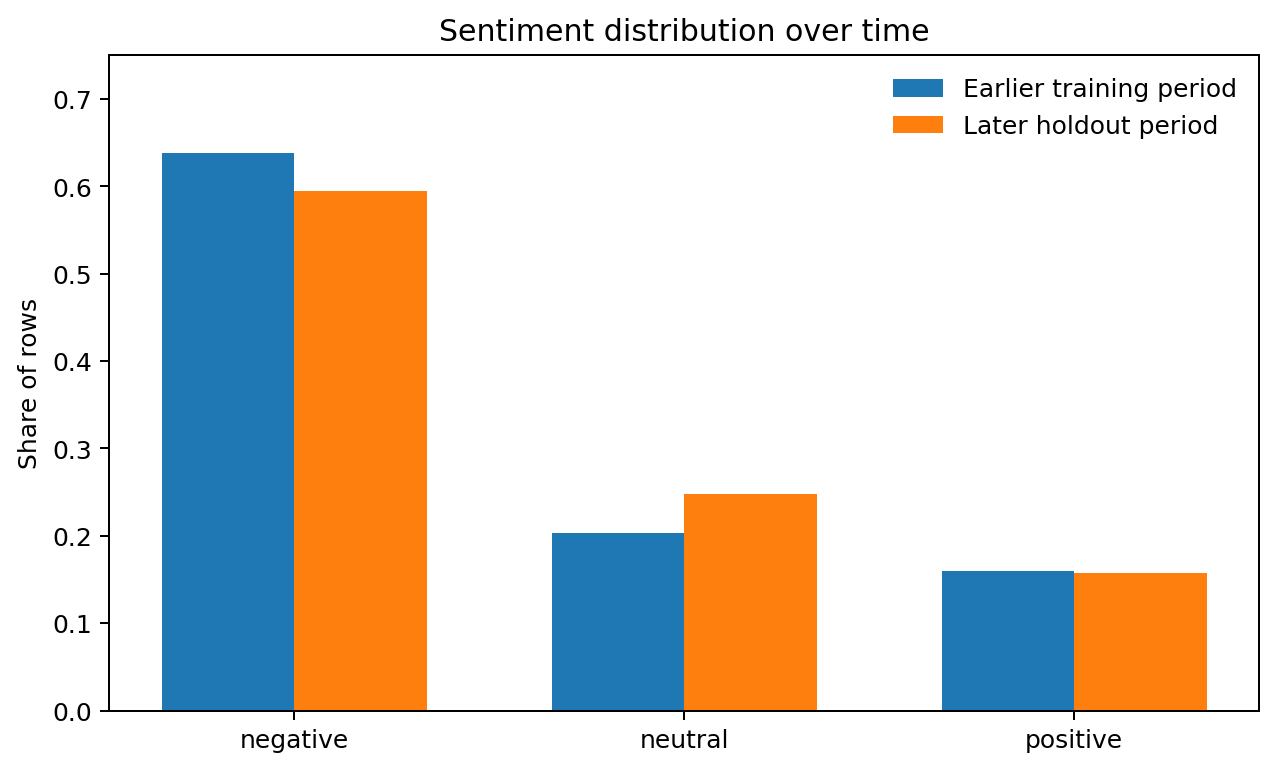

In [4]:
features = pd.read_csv(METRICS / 'top_features.csv')
display(features.groupby('class').head(10))
display(Image(filename=str(FIGURES / 'class_distribution.png')))

## Limitations

- The data covers roughly one week in February 2015.
- A later-message holdout is stronger than a random split but does not prove generalization to current language, other platforms, or other industries.
- Neutral sentiment remains materially harder to classify.
- Public social-media labels can contain annotation and representation bias.